# 실습 5-1 : Feature Selection (mRMR, Boruta)

#### **<실습 개요>**

1. 다중공선성 확인 : 상관행렬 히트맵 시각화
2. mRMR 적용 : 선택/제거된 변수 수 확인, 성능 및 히트맵 비교
3. Boruta 적용 : 선택/제거된 변수 수 확인, 성능 및 히트맵 비교
4. 성능 비교 요약 : 전체 변수 vs mRMR vs Boruta

## 분석 준비

### 주요 라이브러리 호출

In [1]:
# mRMR, boruta 설치
!pip install mrmr-selection boruta

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 802.4/802.4 kB 4.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 39.3/39.3 MB 16.7 MB/s  0:00:02m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [mrmr-selection]m [polars]


In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import KFold

# 회귀 모델 및 성능 평가 지표
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 데이터 분할
from sklearn.model_selection import train_test_split

# Boruta 내부에서 변수 중요도를 계산할 때 사용하는 앙상블 모델
from sklearn.ensemble import RandomForestRegressor

In [3]:
# 회귀 성능 평가 함수 (이후 전체 변수 / mRMR / Boruta 결과를 같은 기준으로 비교하기 위해 정의)
def get_regscore(true, pred):
    print("MSE       : %.3f" % mean_squared_error(true, pred))
    print("MAE       : %.3f" % mean_absolute_error(true, pred))
    print("R-squared : %.3f" % r2_score(true, pred))

---

## 1) 데이터 준비

- 공정 중 여러 구간에서 수집한 센서 통계값(표준편차, 평균, 범위)으로 최종 계측값(Y)을 예측하는 회귀 데이터셋

In [4]:
data = pd.read_csv(("dataset/day5-1_data.csv"), encoding="EUC-KR")
data

,자재구분,END_DATE_TIME,Y,CHAMBER,TAE.STDDEV0,TAE.MEAN0,TAE.RANGE0,PC.STDDEV0,PC.MEAN0,PC.RANGE0,...,TAE.STDDEV9,TAE.MEAN9,TAE.RANGE9,CROT.STDDEV9,CROT.MEAN9,CROT.RANGE9,PC.STDDEV9,PC.MEAN9,PC.RANGE9,PC.RANGE11.1
0,1,2017-09-25 16:18,69,4,0.044554,38.083127,0.254154,0.124753,0.044329,0.439883,...,0.032832,35.011650,0.127077,0,35,0,0.405343,45.124841,3.079182,NaN
1,2,2017-09-25 16:13,28,2,0.034801,38.052395,0.063538,0.177575,0.342131,0.439883,...,0.020858,35.550245,0.063540,0,27,0,1.923012,45.350277,15.004887,NaN
2,3,2017-09-25 16:15,13,3,0.030089,38.046407,0.127080,0.137559,0.063983,0.488759,...,0.021635,36.013373,0.063538,0,15,0,0.161640,45.071393,0.977516,NaN
3,4,2017-09-25 16:10,101,4,0.047904,38.090810,0.190617,1.441465,0.503421,6.549365,...,0.025405,35.020727,0.127077,0,35,0,0.359273,45.110758,2.688171,NaN
4,5,2017-10-05 3:48,319,3,0.036058,38.023829,0.190617,0.116419,0.045446,0.391007,...,0.076083,33.967311,0.317697,0,58,0,0.447676,45.147192,3.225808,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
134,135,2018-01-25 13:18,27,3,0.027780,38.064804,0.063536,0.306206,0.342131,1.124145,...,0.025479,36.533647,0.127079,0,65,0,0.325076,45.069147,3.176930,3.176930
135,136,2018-01-25 13:10,23,3,0.033961,38.077084,0.063536,0.163848,0.502723,0.488759,...,0.033529,36.548598,0.127079,0,64,0,0.668920,45.131644,5.180838,5.180838
136,137,2018-01-25 13:13,56,3,0.031002,38.068007,0.063536,0.177190,0.481776,0.537634,...,0.026805,36.535092,0.127079,0,64,0,0.613599,44.972303,4.985336,4.985336
137,138,2018-01-25 13:15,78,2,0.031002,38.068007,0.063536,0.170316,0.349113,0.439883,...,0.038289,36.022728,0.127080,0,22,0,1.382720,45.285845,10.801564,10.801564


### 1-1) 전처리

In [5]:
# 식별자, 시간 정보 컬럼과 결측치가 있는 컬럼 제거
data.drop(["자재구분", "END_DATE_TIME"], axis=1, inplace=True)
data.dropna(axis=1, inplace=True)

# 값이 모두 동일해 분산이 0인 변수는 모델 학습에 아무 정보도 주지 못하므로 제거
for col in data.columns:
    if len(data[col].unique()) == 1:
        data.drop([col], axis=1, inplace=True)

print("최종 데이터 크기:", data.shape)

최종 데이터 크기: (139, 117)


In [6]:
X = data.drop("Y", axis=1)
Y = data["Y"]

# random_state를 고정해 이후 mRMR/Boruta 비교 실험이 동일한 학습/검증 데이터로 진행되도록 함
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, random_state=42)

---

### 1-2) 다중공선성 확인

> **다중공선성(Multicollinearity)**
>
> 입력변수 간 상관관계가 높아 모델의 안정성과 해석력이 저하되는 현상
>
> **해결 방법**
>
> 차원 축소(Dimensionality Reduction)
> - Feature Selection : mRMR, Boruta
> - Feature Extraction : PCA

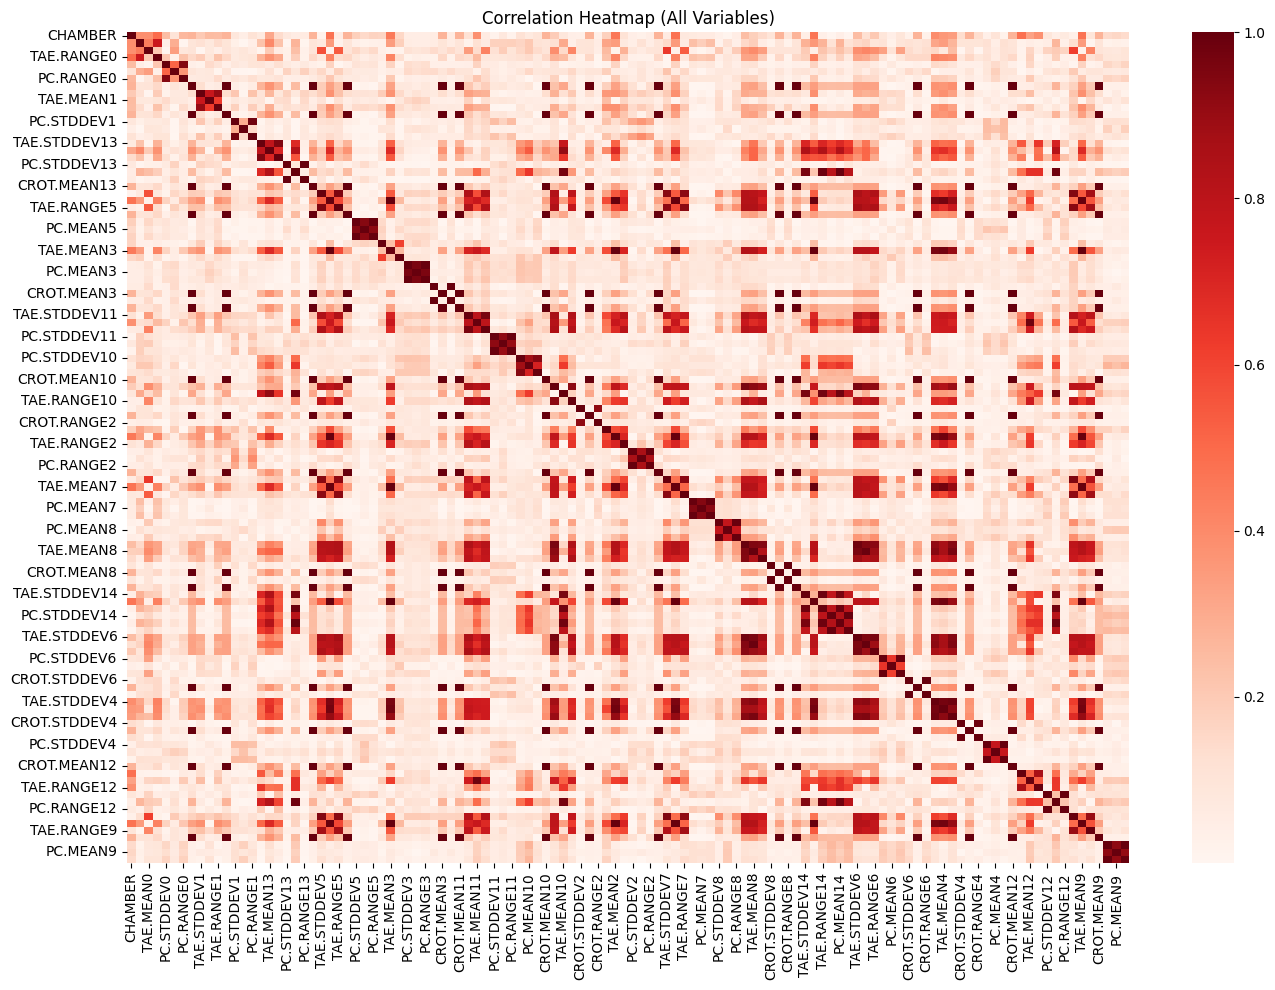

In [7]:
plt.figure(figsize=(14, 10))
sns.heatmap(abs(X.corr()), cmap='Reds')
plt.title("Correlation Heatmap (All Variables)")
plt.tight_layout()
plt.show()

In [8]:
# 변수 선택 전 baseline 성능 (이후 mRMR/Boruta 결과와 비교할 기준점)
lr_all = LinearRegression()
lr_all.fit(X_train, Y_train)
pred_all = lr_all.predict(X_test)
print("[전체 변수 사용]")
get_regscore(Y_test, pred_all)

[전체 변수 사용]
MSE       : 94210.388
MAE       : 213.011
R-squared : -15.511


/opt/homebrew/Caskroom/miniconda/base/envs/day3/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/opt/homebrew/Caskroom/miniconda/base/envs/day3/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/opt/homebrew/Caskroom/miniconda/base/envs/day3/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_


---

## 2) 변수 선택법 적용

### 2-1) mRMR

> **mRMR**
>
> 입력변수들 간의 상관관계는 **최소화(Minimum Redundancy)** 하고, 입력변수와 출력변수 간의 상관관계는 **최대화(Maximum Relevance)** 하는 변수 선택 방법
> - Pearson 상관계수를 사용하여 변수 간 관계를 파악
> - 하이퍼파라미터 $k$: 선택할 변수의 개수

In [9]:
from mrmr import mrmr_regression

# mRMR로 상위 k개 변수 선택 (하이퍼파라미터)
k = 15
selected_mrmr = mrmr_regression(X_train, Y_train, K=k)
removed_mrmr = [col for col in X.columns if col not in selected_mrmr]

print(f"mRMR 선택 변수 ({len(selected_mrmr)}개):", selected_mrmr)
print(f"mRMR 제거 변수 : {len(removed_mrmr)}개 (전체 {X.shape[1]}개 중 {len(selected_mrmr)}개만 사용)")

100%|██████████| 15/15 [00:00<00:00, 76.11it/s]

mRMR 선택 변수 (15개): ['CROT.MEAN4', 'PC.STDDEV5', 'TAE.MEAN6', 'CROT.MEAN5', 'TAE.MEAN8', 'CROT.MEAN6', 'CROT.STDDEV3', 'CROT.MEAN7', 'TAE.RANGE4', 'CROT.MEAN8', 'PC.STDDEV0', 'CROT.MEAN3', 'TAE.STDDEV4', 'CROT.MEAN0', 'CROT.MEAN13']
mRMR 제거 변수 : 101개 (전체 116개 중 15개만 사용)


In [10]:
# mRMR 기반으로 선택된 변수만으로 다시 학습해 성능 추출
lr_mrmr = LinearRegression()
lr_mrmr.fit(X_train[selected_mrmr], Y_train)
pred_mrmr = lr_mrmr.predict(X_test[selected_mrmr])
print("[mRMR 선택 변수 사용]")
get_regscore(Y_test, pred_mrmr)

[mRMR 선택 변수 사용]
MSE       : 4494.179
MAE       : 44.956
R-squared : 0.212


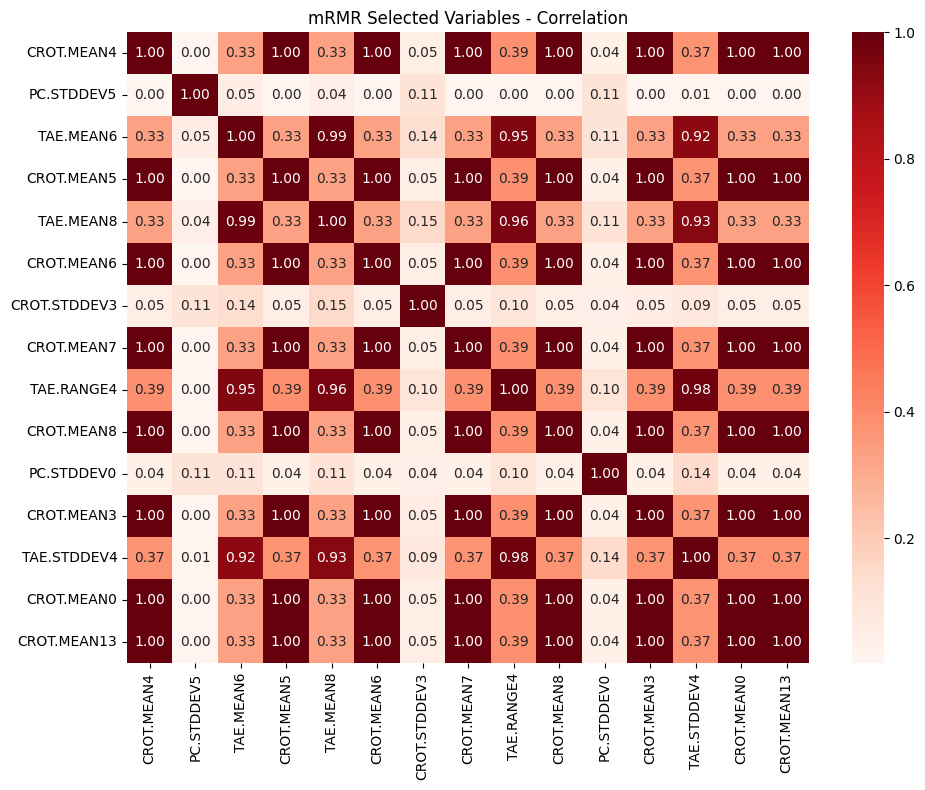

In [11]:
# mRMR 적용 이후 Heatmap 확인
plt.figure(figsize=(10, 8))
sns.heatmap(abs(X[selected_mrmr].corr()), cmap='Reds', annot=True, fmt=".2f")
plt.title("mRMR Selected Variables - Correlation")
plt.tight_layout()
plt.show()

In [12]:
# k-fold cross validation을 활용해 후보 k값들 중 최적의 k값 찾기
k_candidates = [3, 5, 7, 10, 15]
kf = KFold(n_splits=5, shuffle=True, random_state=42)

k_scores = {}

for k in k_candidates:
    # 전체 학습 데이터 기준으로 mRMR 변수 선택 
    selected = mrmr_regression(X_train, Y_train, K=k)
    
    fold_scores = []
    for train_idx, val_idx in kf.split(X_train):
        X_tr, X_val = X_train.iloc[train_idx][selected], X_train.iloc[val_idx][selected]
        y_tr, y_val = Y_train.iloc[train_idx], Y_train.iloc[val_idx]
        
        model = LinearRegression()
        model.fit(X_tr, y_tr)
        pred = model.predict(X_val)
        fold_scores.append(mean_squared_error(y_val, pred)) # MSE 기준
    
    k_scores[k] = np.mean(fold_scores)
    print(f"k={k}, 변수={selected}, 평균 MSE={k_scores[k]:.4f}")

100%|██████████| 3/3 [00:00<00:00, 68.92it/s]


k=3, 변수=['CROT.MEAN4', 'PC.STDDEV5', 'TAE.MEAN6'], 평균 MSE=1827.2074


100%|██████████| 5/5 [00:00<00:00, 84.26it/s]


k=5, 변수=['CROT.MEAN4', 'PC.STDDEV5', 'TAE.MEAN6', 'CROT.MEAN5', 'TAE.MEAN8'], 평균 MSE=1919.6131


100%|██████████| 7/7 [00:00<00:00, 82.65it/s]


k=7, 변수=['CROT.MEAN4', 'PC.STDDEV5', 'TAE.MEAN6', 'CROT.MEAN5', 'TAE.MEAN8', 'CROT.MEAN6', 'CROT.STDDEV3'], 평균 MSE=1961.4725


100%|██████████| 10/10 [00:00<00:00, 76.97it/s]


k=10, 변수=['CROT.MEAN4', 'PC.STDDEV5', 'TAE.MEAN6', 'CROT.MEAN5', 'TAE.MEAN8', 'CROT.MEAN6', 'CROT.STDDEV3', 'CROT.MEAN7', 'TAE.RANGE4', 'CROT.MEAN8'], 평균 MSE=2199.8306


100%|██████████| 15/15 [00:00<00:00, 73.78it/s]

k=15, 변수=['CROT.MEAN4', 'PC.STDDEV5', 'TAE.MEAN6', 'CROT.MEAN5', 'TAE.MEAN8', 'CROT.MEAN6', 'CROT.STDDEV3', 'CROT.MEAN7', 'TAE.RANGE4', 'CROT.MEAN8', 'PC.STDDEV0', 'CROT.MEAN3', 'TAE.STDDEV4', 'CROT.MEAN0', 'CROT.MEAN13'], 평균 MSE=2696.1711


In [13]:
# 가장 성능 좋은(MSE 최소) k 선택
best_k = min(k_scores, key=k_scores.get)
print(f"최적 k: {best_k} (MSE={k_scores[best_k]:.4f})")

# 최적 k로 최종 변수 선택
selected_mrmr = mrmr_regression(X_train, Y_train, K=best_k)
removed_mrmr = [col for col in X.columns if col not in selected_mrmr]

print(f"mRMR 선택 변수 ({len(selected_mrmr)}개):", selected_mrmr)
print(f"mRMR 제거 변수 : {len(removed_mrmr)}개 (전체 {X.shape[1]}개 중 {len(selected_mrmr)}개만 사용)")

최적 k: 3 (MSE=1827.2074)


100%|██████████| 3/3 [00:00<00:00, 97.84it/s]

mRMR 선택 변수 (3개): ['CROT.MEAN4', 'PC.STDDEV5', 'TAE.MEAN6']
mRMR 제거 변수 : 113개 (전체 116개 중 3개만 사용)


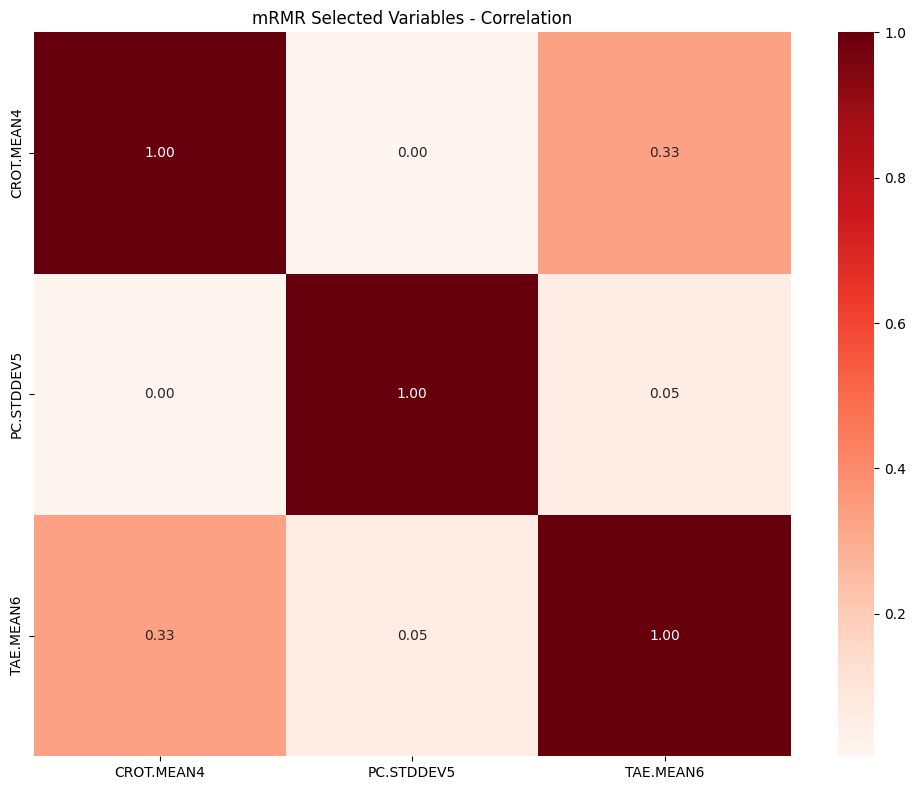

In [14]:
# mRMR를 기반으로 변수를 줄인 뒤 다중공선성이 얼마나 완화됐는지 수치로 확인
plt.figure(figsize=(10, 8))
sns.heatmap(abs(X[selected_mrmr].corr()), cmap='Reds', annot=True, fmt=".2f")
plt.title("mRMR Selected Variables - Correlation")
plt.tight_layout()
plt.show()

In [15]:
# best_k 변수로 최종 학습 후 X_test 성능 평가
lr_mrmr = LinearRegression()
lr_mrmr.fit(X_train[selected_mrmr], Y_train) 
pred_mrmr = lr_mrmr.predict(X_test[selected_mrmr])

print("[mRMR 선택 변수 사용 - Test 성능]")
get_regscore(Y_test, pred_mrmr)

[mRMR 선택 변수 사용 - Test 성능]
MSE       : 3731.451
MAE       : 40.361
R-squared : 0.346


---

### 2-2) Boruta

> **Boruta**
>
> 출력변수를 예측하는 데 필요한 **모든 관련 변수(All Relevant Features)** 를 선택하는 방법
>
> - 입력변수의 값을 무작위로 섞은 **Shadow Feature**를 생성
> - Random Forest로 변수 중요도를 계산하여 Shadow Feature 보다 높은 중요도를 가진 변수만 선택

In [16]:
from boruta import BorutaPy

# n_estimators='auto' : 트리 개수 자동 설정
# max_iter=10 : 반복 판단 횟수 (많을수록 정확하지만 느림)
# perc=100 : 판단 기준 엄격도 (100=가장 엄격, 낮을수록 변수 더 많이 통과)

rf = RandomForestRegressor(random_state=42)
selected_boruta = BorutaPy(rf, n_estimators='auto', max_iter=10, perc=100, random_state=42)

# BorutaPy는 numpy 배열만 지원 -> DataFrame을 values로 변환
# Y는 1차원 배열이어야 하므로 ravel() 적용
selected_boruta.fit(X_train.values, Y_train.values.ravel())

print("총 변수:", X.shape[1])
print("Boruta 확정 변수:", selected_boruta.n_features_)

총 변수: 116
Boruta 확정 변수: 1


> Bourta의 3가지 판단 상태

| 상태 | 의미 | 관련 속성 |
|---|---|---|
| 확정 (Confirmed) | 진짜 유의미한 변수라고 확실히 판단 | `support_` |
| 미정 (Tentative) | 유의미한지 애매하게 끝남 | `support_weak_` |
| 기각 (Rejected) | 의미 없다고 판단 | 둘 다 False |

In [17]:
# 확정 변수(support_)와 판단이 애매한 미정 변수(support_weak_)를 구분해서 확인
boruta_cols = X_train.columns[selected_boruta.support_].tolist()
boruta_tentative = X_train.columns[selected_boruta.support_weak_].tolist()

# 미정 변수 중요도 계산용 랜덤포레스트를 데이터 전체로 별도 학습 (Boruta 내부 rf와 별개)
rf_importance = RandomForestRegressor(random_state=42)
rf_importance.fit(X_train, Y_train)
importances = rf_importance.feature_importances_

tentative_ranked = sorted(boruta_tentative, key=lambda c: importances[X_train.columns.get_loc(c)], reverse=True)

print("확정 변수:", boruta_cols)
print("미정 변수(중요도 순):", tentative_ranked)

확정 변수: ['TAE.MEAN7']
미정 변수(중요도 순): ['TAE.MEAN5', 'TAE.STDDEV13', 'TAE.MEAN10', 'TAE.MEAN12', 'CROT.MEAN13']


In [18]:
# 미정 변수를 0개~5개까지 추가하며 k-fold로 성능 비교
kf = KFold(n_splits=5, shuffle=True, random_state=42)
n_candidates = range(0, min(5, len(tentative_ranked)) + 1)

n_scores = {}

for n in n_candidates:
    use_cols = boruta_cols + tentative_ranked[:n]
    
    fold_scores = []
    for train_idx, val_idx in kf.split(X_train):
        X_tr, X_val = X_train.iloc[train_idx][use_cols], X_train.iloc[val_idx][use_cols]
        y_tr, y_val = Y_train.iloc[train_idx], Y_train.iloc[val_idx]
        
        model = LinearRegression()
        model.fit(X_tr, y_tr)
        pred = model.predict(X_val)
        fold_scores.append(mean_squared_error(y_val, pred))
    
    n_scores[n] = np.mean(fold_scores)
    print(f"미정 변수 {n}개 추가, 평균 MSE={n_scores[n]:.4f}")

미정 변수 0개 추가, 평균 MSE=2530.5618
미정 변수 1개 추가, 평균 MSE=2525.6161
미정 변수 2개 추가, 평균 MSE=2515.9683
미정 변수 3개 추가, 평균 MSE=2675.1350
미정 변수 4개 추가, 평균 MSE=2503.8725
미정 변수 5개 추가, 평균 MSE=2014.0646


In [19]:
# 최적 개수 선택
best_n = min(n_scores, key=n_scores.get)
print(f"최적 미정 변수 개수: {best_n} (MSE={n_scores[best_n]:.4f})")

최적 미정 변수 개수: 5 (MSE=2014.0646)


In [20]:
# 최적 조합으로 최종 학습 및 Test 평가
selected_boruta_final = boruta_cols + tentative_ranked[:best_n]
print(f"최종 사용 변수 ({len(use_cols)}개):", use_cols)

lr_boruta = LinearRegression()
lr_boruta.fit(X_train[selected_boruta_final], Y_train)
pred_boruta = lr_boruta.predict(X_test[selected_boruta_final])
print("[Boruta 선택 변수 사용 - Test 성능]")
get_regscore(Y_test, pred_boruta)

최종 사용 변수 (6개): ['TAE.MEAN7', 'TAE.MEAN5', 'TAE.STDDEV13', 'TAE.MEAN10', 'TAE.MEAN12', 'CROT.MEAN13']
[Boruta 선택 변수 사용 - Test 성능]
MSE       : 3890.515
MAE       : 40.315
R-squared : 0.318


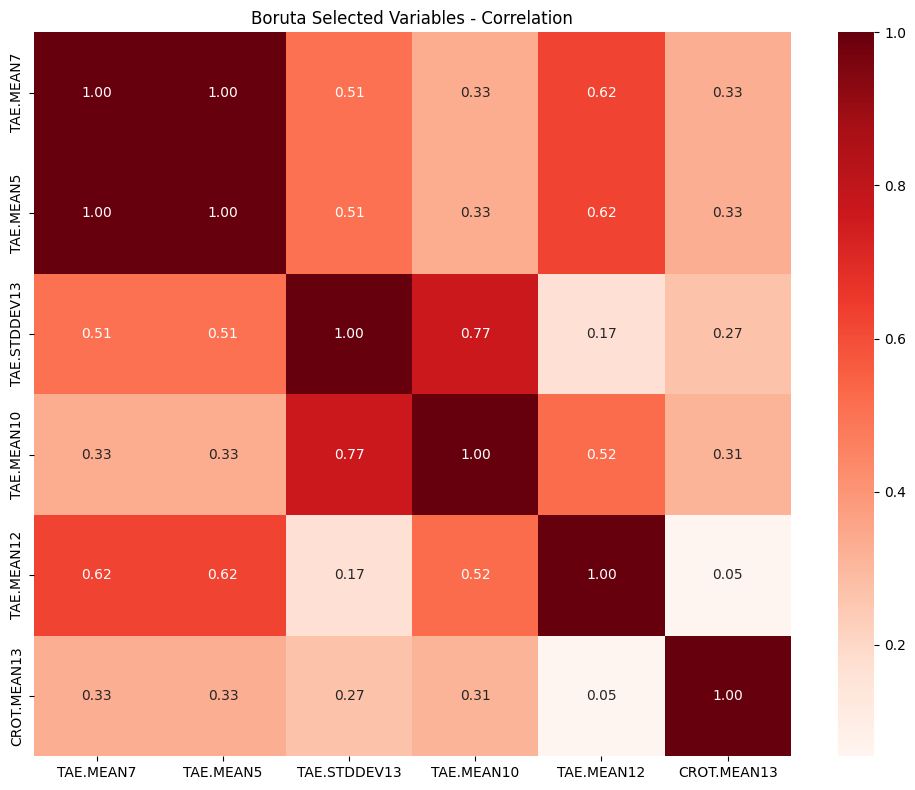

In [21]:
# Boruta를 기반으로 변수를 줄인 뒤 다중공선성이 얼마나 완화됐는지 수치로 확인
plt.figure(figsize=(10, 8))
sns.heatmap(abs(X[selected_boruta_final].corr()), cmap='Reds', annot=True, fmt=".2f")
plt.title("Boruta Selected Variables - Correlation")
plt.tight_layout()
plt.show()

### 2-3) 성능 비교 요약

In [22]:
results = pd.DataFrame({
    "Method": ["전체 변수", f"mRMR (k={best_k})", f"Boruta ({len(selected_boruta_final)}개)"],
    "변수 수": [X.shape[1], best_k, len(use_cols)],
    "MAE": [
        round(mean_absolute_error(Y_test, pred_all), 2),
        round(mean_absolute_error(Y_test, pred_mrmr), 2),
        round(mean_absolute_error(Y_test, pred_boruta), 2)
    ],
    "R-squared": [
        round(r2_score(Y_test, pred_all), 3),
        round(r2_score(Y_test, pred_mrmr), 3),
        round(r2_score(Y_test, pred_boruta), 3)
    ]
})

results

,Method,변수 수,MAE,R-squared
0,전체 변수,116,213.01,-15.511
1,mRMR (k=3),3,40.36,0.346
2,Boruta (6개),6,40.32,0.318


> **분류 문제였다면?**
>
> - mRMR은 `mrmr_regression` → `mrmr_classif`
> - Boruta는 `RandomForestRegressor` → `RandomForestClassifier`

---

## 3) Vibe Coding 실습

**[과제 1]** 

지수는 mRMR과 Boruta가 서로 다른 원리로 변수를 선택한다는 것을 배웠습니다.

AI와 함께 동일한 데이터에 mRMR과 Boruta를 적용하여 선택된 변수를 비교해 보세요. 

두 방법에서 공통으로 선택된 변수와 한 방법에서만 선택된 변수를 확인하고 왜 이러한 차이가 발생했는지 AI와 토의하여 해석해 보세요.

In [23]:
mrmr_set = set(selected_mrmr)
boruta_set = set(selected_boruta_final)

print("mRMR :", selected_mrmr)
print("Boruta:", selected_boruta_final)
print("공통 :", sorted(mrmr_set & boruta_set))
print("mRMR만:", sorted(mrmr_set - boruta_set))
print("Boruta만:", sorted(boruta_set - mrmr_set))

pd.DataFrame({
    "Method": ["전체", f"mRMR(k={best_k})", f"Boruta({len(selected_boruta_final)})"],
    "변수수": [X.shape[1], len(selected_mrmr), len(selected_boruta_final)],
    "MSE": [mean_squared_error(Y_test, p) for p in [pred_all, pred_mrmr, pred_boruta]],
    "R2": [r2_score(Y_test, p) for p in [pred_all, pred_mrmr, pred_boruta]],
}).round(3)

mRMR : ['CROT.MEAN4', 'PC.STDDEV5', 'TAE.MEAN6']
Boruta: ['TAE.MEAN7', 'TAE.MEAN5', 'TAE.STDDEV13', 'TAE.MEAN10', 'TAE.MEAN12', 'CROT.MEAN13']
공통 : []
mRMR만: ['CROT.MEAN4', 'PC.STDDEV5', 'TAE.MEAN6']
Boruta만: ['CROT.MEAN13', 'TAE.MEAN10', 'TAE.MEAN12', 'TAE.MEAN5', 'TAE.MEAN7', 'TAE.STDDEV13']


,Method,변수수,MSE,R2
0,전체,116,94210.388,-15.511
1,mRMR(k=3),3,3731.451,0.346
2,Boruta(6),6,3890.515,0.318
